# Lab Assignment 12: Probability, Simulation, and Estimation

Please complete this notebook by filling in the cells provided. Before you begin, execute the previous cell to load the provided tests.

**Helpful Resource:**
- [Python Reference](http://data8.org/sp24/reference/): Cheat sheet of helpful array & table methods used!
- [Sampling Methods Guide](https://drive.google.com/file/d/1k8uNN0Bg7J0BTgK-0Z5glDNtd_5FTJQl/view?usp=sharing): Guide for the randomization methods.

**Recommended Readings**:
* [Randomness](https://www.inferentialthinking.com/chapters/09/Randomness.html)

In [76]:
!apt-get install texlive texlive-xetex texlive-latex-extra pandoc
!pip install pypandoc
!pip install datascience

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pandoc is already the newest version (2.9.2.1-3ubuntu2).
texlive is already the newest version (2021.20220204-1).
texlive-latex-extra is already the newest version (2021.20220204-1).
texlive-xetex is already the newest version (2021.20220204-1).
0 upgraded, 0 newly installed, 0 to remove and 38 not upgraded.


In [77]:
# Connect Google Drive to Colab so you can access your files
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/Colab Notebooks/')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Roulette

In [78]:
# Run this cell to set up the notebook, but please don't change it.

# These lines import the Numpy and Datascience modules.
import numpy as np
from datascience import *

# These lines do some fancy plotting magic.
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import warnings
warnings.simplefilter('ignore', FutureWarning)

A Nevada roulette wheel has 38 pockets and a small ball that rests on the wheel. When the wheel is spun, the ball comes to rest in one of the 38 pockets. That pocket is declared the winner.

The pockets are labeled 0, 00, 1, 2, 3, 4, ... , 36. Pockets 0 and 00 are green, and the other pockets are alternately red and black. The table `wheel` is a representation of a Nevada roulette wheel. **Note that *both* columns consist of strings.** Below is an example of a roulette wheel!

<img src="https://github.com/data-8/materials-sp24/blob/main/hw/hw06/roulette_wheel.jpeg?raw=1" width="330px">

Run the cell below to load the `wheel` table.

In [79]:
wheel = Table.read_table('./DS/roulette_wheel.csv', dtype=str)
wheel

Pocket,Color
00,green
0,green
1,red
2,black
3,red
4,black
5,red
6,black
7,red
8,black


### Betting on Red ###
If you bet on *red*, you are betting that the winning pocket will be red. This bet *pays 1 to 1*. That means if you place a one-dollar bet on red, then:

- If the winning pocket is red, you gain 1 dollar. That is, you get your original dollar back, plus one more dollar.
- If the winning pocket is not red, you lose your dollar. In other words, you gain -1 dollars.

Let's see if you can make money by betting on red at roulette.

**Question 1.** Define a function `dollar_bet_on_red` that takes the name of a color and returns your gain in dollars if that color had won and you had placed a one-dollar bet on red. Remember that the gain can be negative. Make sure your function returns an integer. **(4 points)**

*Note:* You can assume that the only colors that will be passed as arguments are red, black, and green. Your function doesn't have to check that.


In [80]:
def dollar_bet_on_red(color):
    if color == 'red':
        return 1
    else:
        return -1

Run the cell below to make sure your function is working.

In [81]:
print(dollar_bet_on_red('green'))
print(dollar_bet_on_red('black'))
print(dollar_bet_on_red('red'))

-1
-1
1


**Question 2.** Add a column labeled `Winnings: Red` to the table `wheel`. For each pocket, the column should contain your gain in dollars if that pocket won and you had bet one dollar on red. Your code should use the function `dollar_bet_on_red`. **(4 points)**

> *Hint:* You should not need a `for` loop for this question, instead try using a table method!

In [82]:
red_winnings = wheel.apply(dollar_bet_on_red, 'Color')
wheel = wheel.with_column('Winnings: Red', red_winnings)
wheel

Pocket,Color,Winnings: Red
00,green,-1
0,green,-1
1,red,1
2,black,-1
3,red,1
4,black,-1
5,red,1
6,black,-1
7,red,1
8,black,-1


### Simulating 10 Bets on Red
Roulette wheels are set up so that each time they are spun, the winning pocket is equally likely to be any of the 38 pockets regardless of the results of all other spins. Let's see what would happen if we decided to bet one dollar on red each round.

**Question 3.** Create a table `ten_bets` by sampling the table `wheel` to simulate 10 spins of the roulette wheel. Your table should have the same three column labels as in `wheel`. Once you've created that table, set `sum_bets` to your net gain in all 10 bets, assuming that you bet one dollar on red each time. **(4 points)**

*Note:* The [Sampling Methods Guide](https://drive.google.com/file/d/1k8uNN0Bg7J0BTgK-0Z5glDNtd_5FTJQl/view?usp=sharing) may be helpful!

*Hint:* It may be helpful to print out `ten_bets` after you create it!

In [83]:
ten_bets = wheel.sample(10, with_replacement=True)
sum_bets = sum(ten_bets.column('Winnings: Red'))
sum_bets

-6

Run the cells above a few times to see how much money you would make if you made 10 one-dollar bets on red. Making a negative amount of money doesn't feel good, but it is a reality in gambling. Casinos are a business, and they make money when gamblers lose.

**Question 4.** Let's see what would happen if you made more bets. Define a function `net_gain_red` that takes the number of bets and returns the net gain in that number of one-dollar bets on red. **(4 points)**

*Hint:* You should use your `wheel` table within your function.


In [84]:
def net_gain_red(num_bets):
    return sum(wheel.sample(num_bets, with_replacement=True).column('Winnings: Red'))

Run the cell below a few times to make sure that the results are similar to those you observed in the previous exercise.

In [85]:
net_gain_red(10)

4

**Question 5.** Complete the cell below to simulate the net gain in 200 one-dollar bets on red, repeating the process 10,000 times. After the cell is run, `simulated_gains_red` should be an array with 10,000 entries, each of which is the net gain in 200 one-dollar bets on red. **(4 points)**

*Hint:* Think about which computational tool might be helpful for simulating a process multiple times. Lab 5 might be a good resource to look at!

*Note:* This cell might take a few seconds to run.


In [86]:
num_bets = 200
repetitions = 10000

simulated_gains_red = np.array([net_gain_red(num_bets) for _ in range(repetitions)])

len(simulated_gains_red) # Do not change this line! Check that simulated_gains_red is length 10000.

10000

Run the cell below to visualize the results of your simulation.

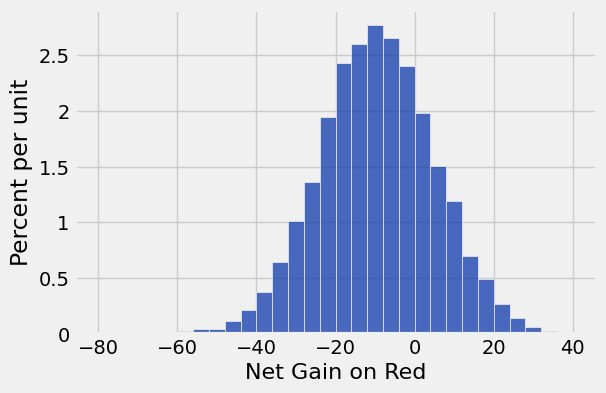

In [87]:
gains = Table().with_columns('Net Gain on Red', simulated_gains_red)
gains.hist(bins = np.arange(-80, 41, 4))

**Question 6:** Using the histogram above, decide whether the following statement is true or false:

>If you make 200 one-dollar bets on red, your chance of losing money is more than 50%.

Assign `loss_more_than_50` to either `True` or `False` depending on your answer to the question. **(2 points)**


In [88]:
loss_more_than_50 = True

### Betting on a Split ###
If betting on red doesn't seem like a good idea, maybe a gambler might want to try a different bet. A bet on a *split* is a bet on two consecutive numbers such as 5 and 6. This bets pays 17 to 1. That means if you place a one-dollar bet on the split 5 and 6, then:

- If the winning pocket is either 5 or 6, your gain is 17 dollars.
- If any other pocket wins, you lose your dollar, so your gain is -1 dollars.

**Question 7.** Define a function `dollar_bet_on_split` that takes a pocket number and returns your gain in dollars if that pocket won and you had bet one dollar on the 5-6 split. **(4 points)**

*Hint:* Remember that the pockets are represented as strings.


In [89]:
def dollar_bet_on_split(pocket):
    if pocket == '5' or pocket == '6':
        return 17
    else:
        return -1

Run the cell below to check that your function is doing what it should.

In [90]:
print(dollar_bet_on_split('5'))
print(dollar_bet_on_split('6'))
print(dollar_bet_on_split('00'))
print(dollar_bet_on_split('23'))

17
17
-1
-1


**Question 8.** Add a column `Winnings: Split` to the `wheel` table. For each pocket, the column should contain your gain in dollars if that pocket won and you had bet one dollar on the 5-6 split. **(4 points)**


In [91]:
split_winnings = wheel.apply(dollar_bet_on_split, 'Pocket')
wheel = wheel.with_column('Winnings: Split', split_winnings)
wheel.show(5) # Do not change this line.

Pocket,Color,Winnings: Red,Winnings: Split
00,green,-1,-1
0,green,-1,-1
1,red,1,-1
2,black,-1,-1
3,red,1,-1


**Question 9.** Simulate the net gain in 200 one-dollar bets on the 5-6 split, repeating the process 10,000 times and saving your gains in the array `simulated_gains_split`. **(5 points)**

*Hint:* Your code in Questions 4 and 5 may be helpful here!


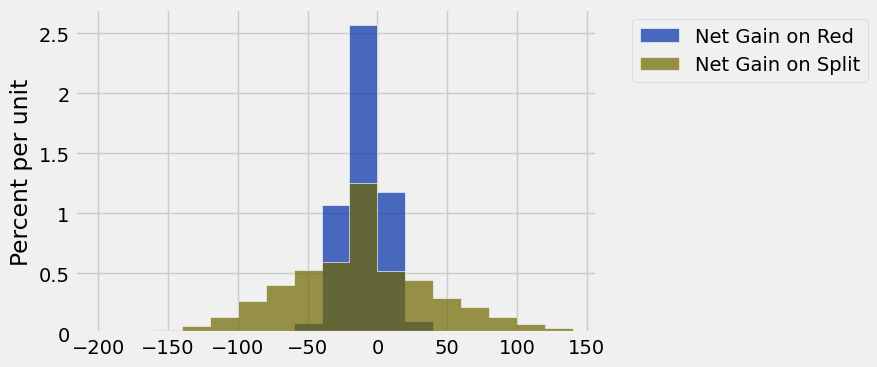

In [92]:
def net_gain_split(num_bets):
    simulated_spins = wheel.sample(num_bets, with_replacement=True)
    return sum(simulated_spins.column('Winnings: Split'))

simulated_gains_split = np.array([net_gain_split(200) for _ in range(10000)])

# Do not change the two lines below
gains = gains.with_columns('Net Gain on Split', simulated_gains_split)
gains.hist(bins = np.arange(-200, 150, 20))

**Question 10.** Look carefully at the visualization above, and assign `histogram_statements` to an array of the numbers of each statement below that can be correctly inferred from the overlaid histogram. **(2 points)**

1. If you bet one dollar 200 times on a split, your chance of losing money is more than 50%.
2. If you bet one dollar 200 times in roulette, your chance of making more than 50 dollars is greater if you bet on a split each time than if you bet on red each time.
3. If you bet one dollar 200 times in roulette, your chance of losing more than 50 dollars is greater if you bet on a split each time than if you bet on red each time.

*Hint:* We've already seen one of these statements in a prior question.


In [93]:
histogram_statements = np.array([1, 2, 3])

If this exercise has put you off playing roulette, it has done its job. If you are still curious about other bets, [here](https://en.wikipedia.org/wiki/Roulette#Bet_odds_table) they all are, and [here](https://en.wikipedia.org/wiki/Roulette#House_edge) is the bad news. The house – that is, the casino – always has an edge over the gambler.

## 2. Chances


Good ways to approach probability calculations include:

- Thinking one trial at a time: What does the first one have to be? Then what does the next one have to be?
- Breaking up the event into distinct ways in which it can happen.
- Seeing if it is easier to find the chance that the event does not happen.

### Finding Chances

On each spin of a roulette wheel, all 38 pockets are equally likely to be the winner regardless of the results of other spins. Among the 38 pockets, 18 are red, 18 black, and 2 green. In each part below, write an expression that evaluates to the chance of the event described.

**Question 1.** The winning pocket is black on all of the first three spins. **(3 points)**


In [94]:
first_three_black = (18/38)**3

**Question 2.** The color green never wins in the first 10 spins. **(3 points)**


In [95]:
no_green = (36/38)**10

**Question 3.** The color green wins **at least once** on the first 10 spins. **(3 points)**


In [96]:
at_least_one_green = 1 - no_green

**Question 4.** Two of the three colors **never** win in the first 10 spins. **(3 points)**

*Hint:* What situation(s) lead to two of the three colors never winning in the first 10 spins?


In [97]:
lone_winners = (18/38)**10 + (18/38)**10 + (2/38)**10

### Comparing Chances
In each of Questions 5-7, two events A and B are described. Choose from one of the following three options and set each answer variable to a single integer:

1. Event A is more likely than Event B
2. Event B is more likely than Event A
3. The two events have the same chance.

You should be able to make the choices **without calculation**. Good ways to approach this exercise include imagining carrying out the chance experiments yourself, one trial at a time, and by thinking about the [law of averages](https://inferentialthinking.com/chapters/10/1/Empirical_Distributions.html#the-law-of-averages).

**Question 5.** A child picks four times at random from a box that has four toy animals: a bear, an elephant, a giraffe, and a kangaroo. **(2 points)**

- Event A: all four different animals are picked (assuming the child picks without replacement)
- Event B: all four different animals are picked (assuming the child picks with replacement)


In [98]:
toys_option = 1

**Question 6.** In a lottery, two numbers are drawn at random with replacement from the integers 1 through 1000. **(2 points)**

- Event A: The number 8 is picked on both draws
- Event B: The same number is picked on both draws


In [99]:
lottery_option = 2

**Question 7.** A fair coin is tossed repeatedly. **(2 points)**

- Event A: There are 60 or more heads in 100 tosses
- Event B: There are 600 or more heads in 1000 tosses

*Hint*: Think about the law of averages!


In [100]:
coin_option = 1

## Submission

Make sure you have run all cells in your notebook in order before running the cell below, so that all images/graphs appear in the output. The cell below will generate a pdf file for you to submit. **Please save before exporting!**

In [102]:
# should change the directory and file name matching to yours
!jupyter nbconvert './DS/lab12(SSU).ipynb' --to pdf

[NbConvertApp] Converting notebook ./DS/lab12(SSU).ipynb to pdf
[NbConvertApp] Support files will be in lab12(SSU)_files/
[NbConvertApp] Making directory ./lab12(SSU)_files
[NbConvertApp] Writing 55696 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 110678 bytes to DS/lab12(SSU).pdf
